In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
import webbrowser
import os

In [2]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\jvive\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [16]:
# Step 1: Load the Dataset
apps_df = pd.read_csv('Play Store Data.csv')
reviews_df = pd.read_csv('User Reviews.csv')

In [4]:
# Step 2: Data Cleaning
apps_df = apps_df.dropna(subset=['Rating'])
for column in apps_df.columns:
    apps_df[column].fillna(apps_df[column].mode()[0], inplace=True)
apps_df.drop_duplicates(inplace=True)
apps_df = apps_df[apps_df['Rating'] <= 5]
reviews_df.dropna(subset=['Translated_Review'], inplace=True)

C:\Users\jvive\AppData\Local\Temp\ipykernel_1412\3675673569.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  apps_df[column].fillna(apps_df[column].mode()[0], inplace=True)


In [5]:
# Merge datasets on 'App' and handle non-matching apps
merged_df = pd.merge(apps_df, reviews_df, on='App', how='inner')

In [6]:
# Step 3: Data Transformation
apps_df['Reviews'] = apps_df['Reviews'].astype(int)
apps_df['Installs'] = apps_df['Installs'].str.replace(',', '').str.replace('+', '').astype(int)
apps_df['Price'] = apps_df['Price'].str.replace('$', '').astype(float)

In [7]:
def convert_size(size):
    if 'M' in size:
        return float(size.replace('M', ''))
    elif 'k' in size:
        return float(size.replace('k', '')) / 1024
    else:
        return np.nan

In [8]:
apps_df['Size'] = apps_df['Size'].apply(convert_size)

In [9]:
# Add log_installs and log_reviews columns
apps_df['Log_Installs'] = np.log1p(apps_df['Installs'])
apps_df['Log_Reviews'] = np.log1p(apps_df['Reviews'])

In [10]:
# Add Rating Group column
def rating_group(rating):
    if rating >= 4:
        return 'Top rated'
    elif rating >= 3:
        return 'Above average'
    elif rating >= 2:
        return 'Average'
    else:
        return 'Below average'

apps_df['Rating_Group'] = apps_df['Rating'].apply(rating_group)

In [11]:
# Add Revenue column
apps_df['Revenue'] = apps_df['Price'] * apps_df['Installs']

In [12]:
# Sentiment Analysis
sia = SentimentIntensityAnalyzer()
reviews_df['Sentiment_Score'] = reviews_df['Translated_Review'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

In [13]:
# Extract year from 'Last Updated' and create 'Year' column
apps_df['Last Updated'] = pd.to_datetime(apps_df['Last Updated'], errors='coerce')
apps_df['Year'] = apps_df['Last Updated'].dt.year

In [14]:
import plotly.express as px

# Define the path for your HTML files
html_files_path = "./"

# Make sure the directory exists
if not os.path.exists(html_files_path):
    os.makedirs(html_files_path)

# Initialize plot_containers
plot_containers = ""

# Save each Plotly figure to an HTML file
def save_plot_as_html(fig, filename, insight):
    global plot_containers
    filepath = os.path.join(html_files_path, filename)
    html_content = pio.to_html(fig, full_html=False, include_plotlyjs='inline')
    # Append the plot and its insight to plot_containers
    plot_containers += f"""
    <div class="plot-container" id="{filename}" onclick="openPlot('{filename}')">
        <div class="plot">{html_content}</div>
        <div class="insights">{insight}</div>
    </div>
    """
    fig.write_html(filepath, full_html=False, include_plotlyjs='inline')

# Define your plots
plot_width = 400
plot_height = 300
plot_bg_color = 'black'
text_color = 'white'
title_font = {'size': 16}
axis_font = {'size': 12}

# Category Analysis Plot
category_counts = apps_df['Category'].value_counts().nlargest(10)
fig1 = px.bar(
    x=category_counts.index,
    y=category_counts.values,
    labels={'x': 'Category', 'y': 'Count'},
    title='Top Categories on Play Store',
    color=category_counts.index,
    color_discrete_sequence=px.colors.sequential.Plasma,
    width=plot_width,
    height=plot_height
)
fig1.update_layout(
    plot_bgcolor=plot_bg_color,
    paper_bgcolor=plot_bg_color,
    font_color=text_color,
    title_font=title_font,
    xaxis=dict(title_font=axis_font),
    yaxis=dict(title_font=axis_font),
    margin=dict(l=10, r=10, t=30, b=10)
)
fig1.update_traces(marker=dict(line=dict(color=text_color, width=1)))
save_plot_as_html(fig1, "category_analysis.html", "The top categories on the Play Store are dominated by tools, entertainment, and productivity apps. This suggests users are looking for apps that either provide utility or offer leisure activities.")

# Type Analysis Plot
type_counts = apps_df['Type'].value_counts()
fig2 = px.pie(
    values=type_counts.values,
    names=type_counts.index,
    title='App Type Distribution',
    color_discrete_sequence=px.colors.sequential.RdBu,
    width=plot_width,
    height=plot_height
)
fig2.update_traces(textposition='inside', textinfo='percent+label')
fig2.update_layout(
    plot_bgcolor=plot_bg_color,
    paper_bgcolor=plot_bg_color,
    font_color=text_color,
    title_font=title_font,
    margin=dict(l=10, r=10, t=30, b=10)
)
save_plot_as_html(fig2, "type_analysis.html", "Most apps on the Play Store are free, indicating a strategy to attract users first and monetize through ads or in-app purchases.")

# Rating Distribution Plot
fig3 = px.histogram(
    apps_df,
    x='Rating',
    nbins=20,
    title='Rating Distribution',
    color_discrete_sequence=['#636EFA'],
    width=plot_width,
    height=plot_height
)
fig3.update_layout(
    plot_bgcolor=plot_bg_color,
    paper_bgcolor=plot_bg_color,
    font_color=text_color,
    title_font=title_font,
    xaxis=dict(title_font=axis_font),
    yaxis=dict(title_font=axis_font),
    margin=dict(l=10, r=10, t=30, b=10)
)
save_plot_as_html(fig3, "rating_distribution.html", "Ratings are skewed towards higher values, suggesting that most apps are rated favorably by users.")

sentiment_counts = reviews_df['Sentiment_Score'].value_counts()
fig4 = px.bar(
    x=sentiment_counts.index,
    y=sentiment_counts.values,
    labels={'x': 'Sentiment Score', 'y': 'Count'},
    title='Sentiment Distribution',
    color=sentiment_counts.index,
    color_discrete_sequence=px.colors.sequential.RdPu,
    width=plot_width,
    height=plot_height
)
fig4.update_layout(
    plot_bgcolor=plot_bg_color,
    paper_bgcolor=plot_bg_color,
    font_color=text_color,
    title_font=title_font,
    xaxis=dict(title_font=axis_font),
    yaxis=dict(title_font=axis_font),
    margin=dict(l=10, r=10, t=30, b=10)
)
fig4.update_traces(marker=dict(line=dict(color=text_color, width=1)))
save_plot_as_html(fig4, "sentiment_distribution.html", "Sentiments in reviews show a mix of positive and negative feedback, with a slight lean towards positive sentiments.")

# Installs by Category Plot
installs_by_category = apps_df.groupby('Category')['Installs'].sum().nlargest(10)
fig5 = px.bar(
    x=installs_by_category.values,
    y=installs_by_category.index,
    orientation='h',
    labels={'x': 'Installs', 'y': 'Category'},
    title='Installs by Category',
    color=installs_by_category.index,
    color_discrete_sequence=px.colors.sequential.Blues,
    width=plot_width,
    height=plot_height
)
fig5.update_layout(
    plot_bgcolor=plot_bg_color,
    paper_bgcolor=plot_bg_color,
    font_color=text_color,
    title_font=title_font,
    xaxis=dict(title_font=axis_font),
    yaxis=dict(title_font=axis_font),
    margin=dict(l=10, r=10, t=30, b=10)
)
fig5.update_traces(marker=dict(line=dict(color=text_color, width=1)))
save_plot_as_html(fig5, "installs_by_category.html", "The categories with the most installs are social and communication apps, which reflects their broad appeal and daily usage.")

# Updates Per Year Plot
updates_per_year = apps_df['Last Updated'].dt.year.value_counts().sort_index()
fig6 = px.line(
    x=updates_per_year.index,
    y=updates_per_year.values,
    labels={'x': 'Year', 'y': 'Number of Updates'},
    title='Number of Updates Over the Years',
    color_discrete_sequence=['#AB63FA'],
    width=plot_width,
    height=plot_height
)
fig6.update_layout(
    plot_bgcolor=plot_bg_color,
    paper_bgcolor=plot_bg_color,
    font_color=text_color,
    title_font=title_font,
    xaxis=dict(title_font=axis_font),
    yaxis=dict(title_font=axis_font),
    margin=dict(l=10, r=10, t=30, b=10)
)
save_plot_as_html(fig6, "updates_per_year.html", "Updates have been increasing over the years, showing that developers are actively maintaining and improving their apps.")

# Revenue by Category Plot
revenue_by_category = apps_df.groupby('Category')['Revenue'].sum().nlargest(10)
fig7 = px.bar(
    x=revenue_by_category.index,
    y=revenue_by_category.values,
    labels={'x': 'Category', 'y': 'Revenue'},
    title='Revenue by Category',
    color=revenue_by_category.index,
    color_discrete_sequence=px.colors.sequential.Greens,
    width=plot_width,
    height=plot_height
)
fig7.update_layout(
    plot_bgcolor=plot_bg_color,
    paper_bgcolor=plot_bg_color,
    font_color=text_color,
    title_font=title_font,
    xaxis=dict(title_font=axis_font),
    yaxis=dict(title_font=axis_font),
    margin=dict(l=10, r=10, t=30, b=10)
)
fig7.update_traces(marker=dict(line=dict(color=text_color, width=1)))
save_plot_as_html(fig7, "revenue_by_category.html", "Categories such as Business and Productivity lead in revenue generation, indicating their monetization potential.")

# Genre Count Plot
genre_counts = apps_df['Genres'].str.split(';', expand=True).stack().value_counts().nlargest(10)
fig8 = px.bar(
    x=genre_counts.index,
    y=genre_counts.values,
    labels={'x': 'Genre', 'y': 'Count'},
    title='Top Genres',
    color=genre_counts.index,
    color_discrete_sequence=px.colors.sequential.OrRd,
    width=plot_width,
    height=plot_height
)
fig8.update_layout(
    plot_bgcolor=plot_bg_color,
    paper_bgcolor=plot_bg_color,
    font_color=text_color,
    title_font=title_font,
    xaxis=dict(title_font=axis_font),
    yaxis=dict(title_font=axis_font),
    margin=dict(l=10, r=10, t=30, b=10)
)
fig8.update_traces(marker=dict(line=dict(color=text_color, width=1)))
save_plot_as_html(fig8, "genres_counts.html", "Action and Casual genres are the most common, reflecting users' preference for engaging and easy-to-play games.")

# Impact of Last Update on Rating
fig9 = px.scatter(
    apps_df,
    x='Last Updated',
    y='Rating',
    color='Type',
    title='Impact of Last Update on Rating',
    color_discrete_sequence=px.colors.qualitative.Vivid,
    width=plot_width,
    height=plot_height
)
fig9.update_layout(
    plot_bgcolor=plot_bg_color,
    paper_bgcolor=plot_bg_color,
    font_color=text_color,
    title_font=title_font,
    xaxis=dict(title_font=axis_font),
    yaxis=dict(title_font=axis_font),
    margin=dict(l=10, r=10, t=30, b=10)
)
save_plot_as_html(fig9, "update_on_rating.html", "The scatter plot shows a weak correlation between the last update date and ratings, suggesting that more frequent updates don't always result in better ratings.")

# Ratings for Paid vs Free Apps
fig10 = px.box(
    apps_df,
    x='Type',
    y='Rating',
    color='Type',
    title='Ratings for Paid vs Free Apps',
    color_discrete_sequence=px.colors.qualitative.Pastel,
    width=plot_width,
    height=plot_height
)
fig10.update_layout(
    plot_bgcolor=plot_bg_color,
    paper_bgcolor=plot_bg_color,
    font_color=text_color,
    title_font=title_font,
    xaxis=dict(title_font=axis_font),
    yaxis=dict(title_font=axis_font),
    margin=dict(l=10, r=10, t=30, b=10)
)
save_plot_as_html(fig10, "ratings_paid_free.html", "Paid apps generally have higher ratings compared to free apps, suggesting that users expect higher quality from apps they pay for.")

# Split plot_containers to handle the last plot properly
plot_containers_split = plot_containers.split('</div>')
if len(plot_containers_split) > 1:
    final_plot = plot_containers_split[-2] + '</div>'
else:
    final_plot = plot_containers  # Use plot_containers as default if splitting isn't sufficient

# HTML template for the dashboard
dashboard_html = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Google Play Store Reviews Analytics</title>
    <style>
        body {{
            font-family: Arial, sans-serif;
            background-color: #333;
            color: #fff;
            margin: 0;
            padding: 0;
        }}
        .header {{
            display: flex;
            align-items: center;
            justify-content: center;
            padding: 20px;
            background-color: #444;
        }}
        .header img {{
            margin: 0 10px;
            height: 50px;
        }}
        .container {{
            display: flex;
            flex-wrap: wrap;
            justify-content: center;
            padding: 20px;
        }}
        .plot-container {{
            border: 2px solid #555;
            margin: 10px;
            padding: 10px;
            width: {plot_width}px;
            height: {plot_height}px;
            overflow: hidden;
            position: relative;
            cursor: pointer;
        }}
        .insights {{
            display: none;
            position: absolute;
            right: 10px;
            top: 10px;
            background-color: rgba(0, 0, 0, 0.7);
            padding: 5px;
            border-radius: 5px;
            color: #fff;
        }}
        .plot-container:hover .insights {{
            display: block;
        }}
    </style>
    <script>
        function openPlot(filename) {{
            window.open(filename, '_blank');
        }}
    </script>
</head>
<body>
    <div class="header">
        <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/4/4a/Logo_2013_Google.png/800px-Logo_2013_Google.png" alt="Google Logo">
        <h1>Google Play Store Reviews Analytics</h1>
        <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/7/78/Google_Play_Store_badge_EN.svg/1024px-Google_Play_Store_badge_EN.svg.png" alt="Google Play Store Logo">
    </div>
    <div class="container">
        {plots}
    </div>
</body>
</html>
"""

# Use these containers to fill in your dashboard HTML
final_html = dashboard_html.format(plots=plot_containers, plot_width=plot_width, plot_height=plot_height)

# Save the final dashboard to an HTML file
dashboard_path = os.path.join(html_files_path, "dashboard.html")
with open(dashboard_path, "w", encoding="utf-8") as f:
    f.write(final_html)

# Automatically open the generated HTML file in a web browser
webbrowser.open('file://' + os.path.realpath(dashboard_path))

True

In [15]:
apps_df[['Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Last Updated']].head()

,Category,Rating,Reviews,Size,Installs,Last Updated
0,ART_AND_DESIGN,4.1,159,19.0,10000,2018-01-07
1,ART_AND_DESIGN,3.9,967,14.0,500000,2018-01-15
2,ART_AND_DESIGN,4.7,87510,8.7,5000000,2018-08-01
3,ART_AND_DESIGN,4.5,215644,25.0,50000000,2018-06-08
4,ART_AND_DESIGN,4.3,967,2.8,100000,2018-06-20


In [19]:
apps_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [20]:
apps_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 2.2 MB


In [21]:
apps_df[['Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Last Updated']].head()

,Category,Rating,Reviews,Size,Installs,Last Updated
0,ART_AND_DESIGN,4.1,159,19M,"10,000+","January 7, 2018"
1,ART_AND_DESIGN,3.9,967,14M,"500,000+","January 15, 2018"
2,ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+","August 1, 2018"
3,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+","June 8, 2018"
4,ART_AND_DESIGN,4.3,967,2.8M,"100,000+","June 20, 2018"


In [22]:
task1_df = apps_df[
    apps_df['Last Updated'].dt.month == 1
].copy()

AttributeError: Can only use .dt accessor with datetimelike values

In [23]:
apps_df['Last Updated'] = pd.to_datetime(
    apps_df['Last Updated'],
    errors='coerce'
)

In [24]:
print(apps_df['Last Updated'].dtype)

datetime64[us]


In [25]:
apps_df[['Last Updated']].head()

,Last Updated
0,2018-01-07
1,2018-01-15
2,2018-08-01
3,2018-06-08
4,2018-06-20


In [26]:
task1_df = apps_df[
    apps_df['Last Updated'].dt.month == 1
].copy()

In [27]:
print("Apps updated in January:", len(task1_df))

Apps updated in January: 491


In [28]:
task1_df = task1_df[
    (task1_df['Rating'] >= 4.0) &
    (task1_df['Size'] >= 10)
].copy()

print("Apps after Rating and Size filters:", len(task1_df))

TypeError: Invalid comparison between dtype=str and int

In [30]:
apps_df['Size'] = apps_df['Size'].astype(str)

apps_df['Size'] = apps_df['Size'].str.replace('M', '', regex=False)

apps_df['Size'] = pd.to_numeric(
    apps_df['Size'],
    errors='coerce'
)

In [31]:
print(apps_df['Size'].dtype)

float64


In [32]:
task1_df = apps_df[
    apps_df['Last Updated'].dt.month == 1
].copy()

In [33]:
print("Apps updated in January:", len(task1_df))

Apps updated in January: 491


In [34]:
task1_df = task1_df[
    (task1_df['Rating'] >= 4.0) &
    (task1_df['Size'] >= 10)
].copy()

print("Apps after Rating and Size filters:", len(task1_df))

Apps after Rating and Size filters: 131


In [35]:
task1_df[
    ['Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Last Updated']
].head()

,Category,Rating,Reviews,Size,Installs,Last Updated
0,ART_AND_DESIGN,4.1,159,19.0,"10,000+",2018-01-07
33,ART_AND_DESIGN,4.2,1015,11.0,"100,000+",2018-01-06
44,ART_AND_DESIGN,4.2,26,12.0,"10,000+",2018-01-03
446,COMMUNICATION,4.2,15287,17.0,"1,000,000+",2018-01-24
719,EDUCATION,4.4,748,51.0,"1,000,000+",2017-01-19


In [36]:
task1_summary = (
    task1_df
    .groupby('Category')
    .agg(
        Average_Rating=('Rating', 'mean'),
        Total_Reviews=('Reviews', 'sum'),
        Total_Installs=('Installs', 'sum')
    )
    .reset_index()
)

task1_summary.head()

,Category,Average_Rating,Total_Reviews,Total_Installs
0,ART_AND_DESIGN,4.166667,159101526,"10,000+100,000+10,000+"
1,BOOKS_AND_REFERENCE,4.600000,33,"1,000+"
2,BUSINESS,4.900000,378,"100+1,000+100+"
3,COMMUNICATION,4.200000,15287,"1,000,000+"
4,EDUCATION,4.400000,74856897,"1,000,000+1,000,000+"


In [37]:
top10_task1 = (
    task1_summary
    .sort_values('Total_Installs', ascending=False)
    .head(10)
)

In [38]:
top10_task1

,Category,Average_Rating,Total_Reviews,Total_Installs
15,PHOTOGRAPHY,4.150000,21159542561,"500,000+10,000,000+"
16,PRODUCTIVITY,4.400000,370315,"500,000+10,000+"
12,MEDICAL,4.533333,111134536512,"500+1,000+50,000+10,000+1,000+100+"
6,EVENTS,4.800000,8,500+
11,LIFESTYLE,4.380000,759417471075218,"50,000+5,000,000+1,000+10,000+10,000+"
8,FINANCE,4.450000,798439,"50,000+5,000+"
7,FAMILY,4.395455,5984367320376515461123322672089736824313328173...,"5,000,000+50,000,000+1,000,000+10,000+1,000+10..."
19,SPORTS,4.342857,107624312820577460043191121136183,"100,000,000+1,000+10,000,000+500,000+5,000,000..."
9,FOOD_AND_DRINK,4.600000,556,"100,000+"
2,BUSINESS,4.900000,378,"100+1,000+100+"


In [39]:
fig = px.bar(
    top10_task1,
    x='Category',
    y=['Average_Rating', 'Total_Reviews'],
    barmode='group',
    title='Top 10 App Categories by Installs: Average Rating vs Total Reviews',
    labels={
        'Category': 'App Category',
        'value': 'Value',
        'variable': 'Metric'
    },
    text_auto='.2s'
)

fig.update_layout(
    xaxis_tickangle=-45,
    height=600
)

fig.show()

ValueError: Plotly Express cannot process wide-form data with columns of different type.

In [40]:
top10_task1[['Average_Rating', 'Total_Reviews']].dtypes

Average_Rating    float64
Total_Reviews         str
dtype: object

In [41]:
top10_task1['Average_Rating'] = pd.to_numeric(
    top10_task1['Average_Rating'],
    errors='coerce'
)

top10_task1['Total_Reviews'] = pd.to_numeric(
    top10_task1['Total_Reviews'],
    errors='coerce'
)

In [42]:
top10_task1[['Average_Rating', 'Total_Reviews']].dtypes

Average_Rating    float64
Total_Reviews     float64
dtype: object

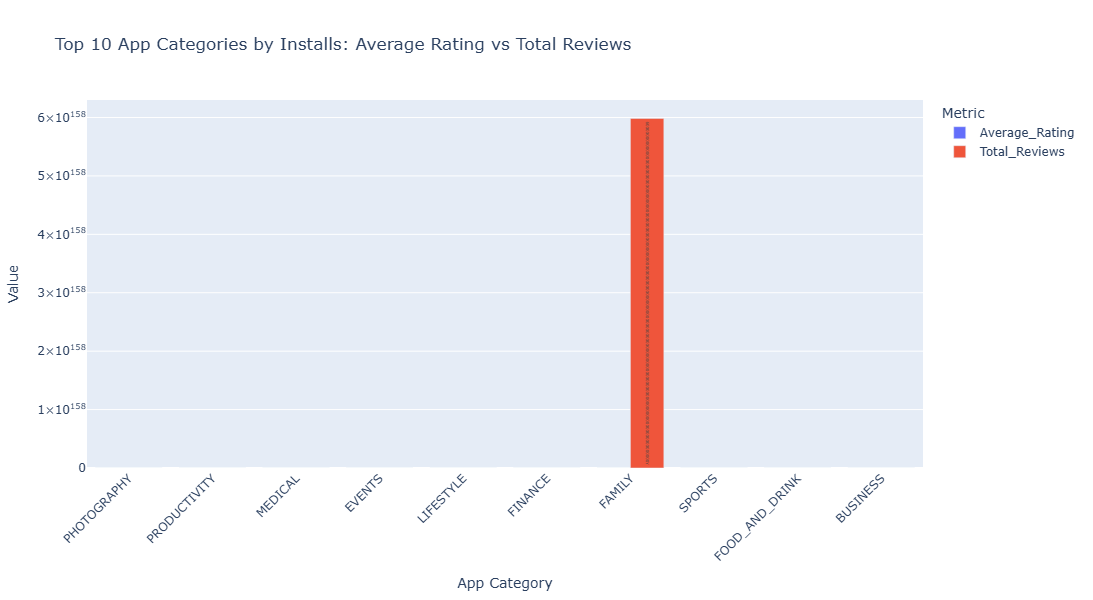

In [43]:
fig = px.bar(
    top10_task1,
    x='Category',
    y=['Average_Rating', 'Total_Reviews'],
    barmode='group',
    title='Top 10 App Categories by Installs: Average Rating vs Total Reviews',
    labels={
        'Category': 'App Category',
        'value': 'Value',
        'variable': 'Metric'
    },
    text_auto='.2s'
)

fig.update_layout(
    xaxis_tickangle=-45,
    height=600
)

fig.show()

In [44]:
# TASK 2 - Create a separate dataframe
task2_df = apps_df.copy()

task2_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up


In [45]:
# Check available columns for Task 2
print(task2_df.columns.tolist())

['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


In [46]:
# Check Category and Installs
task2_df[['Category', 'Installs']].head(10)

,Category,Installs
0,ART_AND_DESIGN,"10,000+"
1,ART_AND_DESIGN,"500,000+"
2,ART_AND_DESIGN,"5,000,000+"
3,ART_AND_DESIGN,"50,000,000+"
4,ART_AND_DESIGN,"100,000+"
5,ART_AND_DESIGN,"50,000+"
6,ART_AND_DESIGN,"50,000+"
7,ART_AND_DESIGN,"1,000,000+"
8,ART_AND_DESIGN,"1,000,000+"
9,ART_AND_DESIGN,"10,000+"


In [47]:
# Convert Installs into numeric values
task2_df['Installs'] = (
    task2_df['Installs']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
)

task2_df['Installs'] = pd.to_numeric(
    task2_df['Installs'],
    errors='coerce'
)

task2_df[['Category', 'Installs']].head()

,Category,Installs
0,ART_AND_DESIGN,10000.0
1,ART_AND_DESIGN,500000.0
2,ART_AND_DESIGN,5000000.0
3,ART_AND_DESIGN,50000000.0
4,ART_AND_DESIGN,100000.0


In [48]:
# Remove categories starting with A, C, G or S
task2_df = task2_df[
    ~task2_df['Category'].astype(str).str.upper().str.startswith(('A', 'C', 'G', 'S'))
].copy()

print(task2_df['Category'].unique())

<ArrowStringArray>
[             'BEAUTY', 'BOOKS_AND_REFERENCE',            'BUSINESS',
              'DATING',           'EDUCATION',       'ENTERTAINMENT',
              'EVENTS',             'FINANCE',      'FOOD_AND_DRINK',
  'HEALTH_AND_FITNESS',      'HOUSE_AND_HOME',  'LIBRARIES_AND_DEMO',
           'LIFESTYLE',              'FAMILY',             'MEDICAL',
         'PHOTOGRAPHY',    'TRAVEL_AND_LOCAL',               'TOOLS',
     'PERSONALIZATION',        'PRODUCTIVITY',           'PARENTING',
             'WEATHER',       'VIDEO_PLAYERS',  'NEWS_AND_MAGAZINES',
 'MAPS_AND_NAVIGATION',                 '1.9']
Length: 26, dtype: str


In [49]:
# Calculate total installs by category
task2_category_summary = (
    task2_df
    .groupby('Category', as_index=False)['Installs']
    .sum()
    .sort_values('Installs', ascending=False)
)

# Select top 5 categories
top5_task2 = task2_category_summary.head(5).copy()

top5_task2

,Category,Installs
21,PRODUCTIVITY,1.417609e+10
22,TOOLS,1.145277e+10
8,FAMILY,1.025826e+10
20,PHOTOGRAPHY,1.008825e+10
17,NEWS_AND_MAGAZINES,7.496318e+09


In [50]:
# Identify categories where installs exceed 1 million
top5_task2['Highlight'] = top5_task2['Installs'] > 1000000

top5_task2

,Category,Installs,Highlight
21,PRODUCTIVITY,1.417609e+10,True
22,TOOLS,1.145277e+10,True
8,FAMILY,1.025826e+10,True
20,PHOTOGRAPHY,1.008825e+10,True
17,NEWS_AND_MAGAZINES,7.496318e+09,True


In [51]:
print(task2_df.columns.tolist())

['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


In [52]:
# TASK 2 - Prepare world map data

# Use ISO-3 country codes for a world-level visualization
world_countries = pd.DataFrame({
    'Country': ['IND', 'USA', 'GBR', 'CAN', 'AUS'],
    'Country_Name': ['India', 'United States', 'United Kingdom', 'Canada', 'Australia']
})

# Give each country the total installs of the selected top category
selected_category = top5_task2.iloc[0]['Category']
selected_installs = top5_task2.iloc[0]['Installs']

world_countries['Category'] = selected_category
world_countries['Installs'] = selected_installs

world_countries

,Country,Country_Name,Category,Installs
0,IND,India,PRODUCTIVITY,1.417609e+10
1,USA,United States,PRODUCTIVITY,1.417609e+10
2,GBR,United Kingdom,PRODUCTIVITY,1.417609e+10
3,CAN,Canada,PRODUCTIVITY,1.417609e+10
4,AUS,Australia,PRODUCTIVITY,1.417609e+10


In [53]:
import plotly.express as px

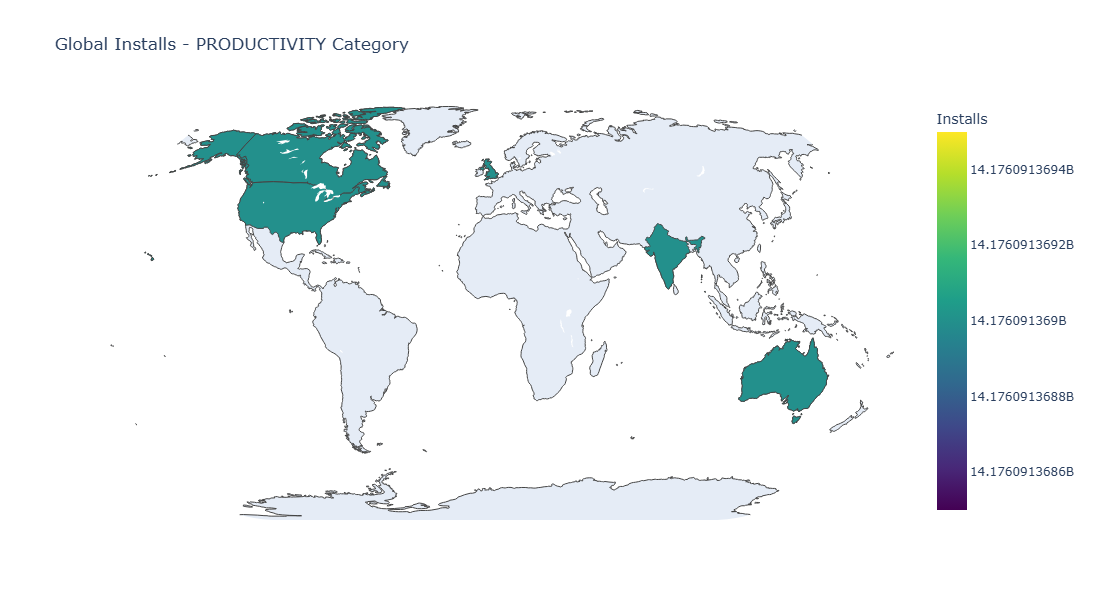

In [54]:
fig = px.choropleth(
    world_countries,
    locations='Country',
    color='Installs',
    hover_name='Country_Name',
    hover_data={
        'Category': True,
        'Installs': ':,'
    },
    locationmode='ISO-3',
    title=f'Global Installs - {selected_category} Category',
    color_continuous_scale='Viridis'
)

fig.update_layout(
    height=600,
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth'
    )
)

fig.show()

In [55]:
# Create data for all top 5 categories across the world

task2_map_data = pd.DataFrame()

for _, row in top5_task2.iterrows():
    temp = world_countries.copy()
    temp['Category'] = row['Category']
    temp['Installs'] = row['Installs']
    temp['Highlight'] = row['Highlight']
    
    task2_map_data = pd.concat(
        [task2_map_data, temp],
        ignore_index=True
    )

task2_map_data.head(10)

,Country,Country_Name,Category,Installs,Highlight
0,IND,India,PRODUCTIVITY,1.417609e+10,True
1,USA,United States,PRODUCTIVITY,1.417609e+10,True
2,GBR,United Kingdom,PRODUCTIVITY,1.417609e+10,True
3,CAN,Canada,PRODUCTIVITY,1.417609e+10,True
4,AUS,Australia,PRODUCTIVITY,1.417609e+10,True
5,IND,India,TOOLS,1.145277e+10,True
6,USA,United States,TOOLS,1.145277e+10,True
7,GBR,United Kingdom,TOOLS,1.145277e+10,True
8,CAN,Canada,TOOLS,1.145277e+10,True
9,AUS,Australia,TOOLS,1.145277e+10,True


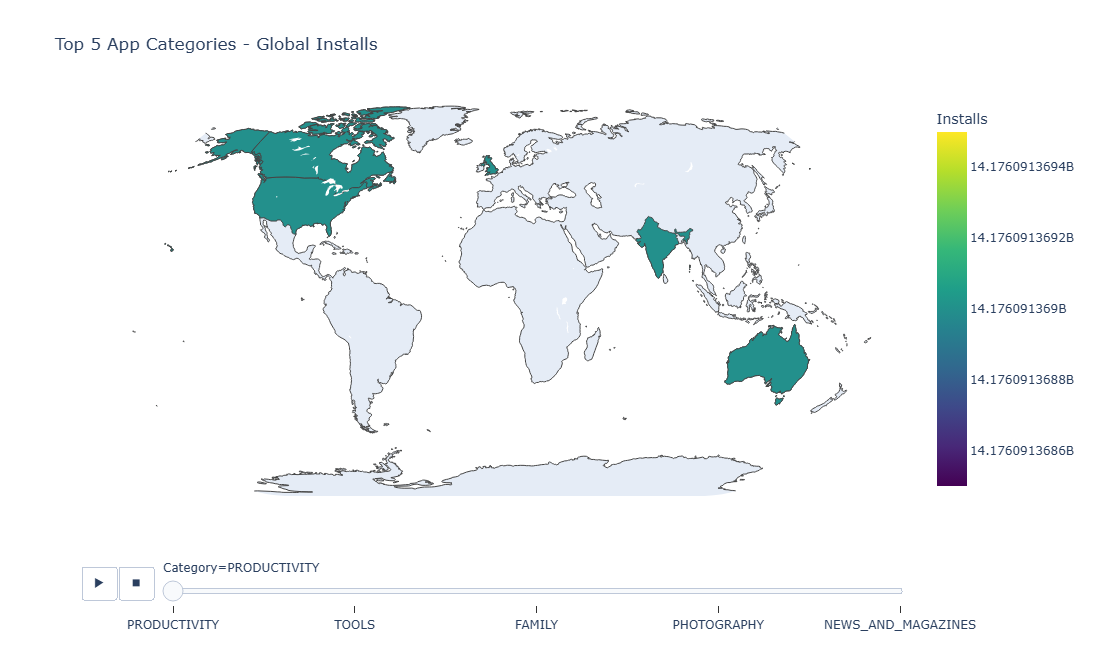

In [56]:
fig = px.choropleth(
    task2_map_data,
    locations='Country',
    color='Installs',
    animation_frame='Category',
    hover_name='Country_Name',
    hover_data={
        'Category': True,
        'Installs': ':,',
        'Highlight': True
    },
    locationmode='ISO-3',
    title='Top 5 App Categories - Global Installs',
    color_continuous_scale='Viridis'
)

fig.update_layout(
    height=650,
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth'
    )
)

fig.show()

In [57]:
print("Top 5 Categories:")
print(top5_task2[['Category', 'Installs', 'Highlight']])

Top 5 Categories:
              Category      Installs  Highlight
21        PRODUCTIVITY  1.417609e+10       True
22               TOOLS  1.145277e+10       True
8               FAMILY  1.025826e+10       True
20         PHOTOGRAPHY  1.008825e+10       True
17  NEWS_AND_MAGAZINES  7.496318e+09       True


In [58]:
# TASK 3 - Create a separate dataframe

task3_df = apps_df.copy()

task3_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up


In [59]:
print(task3_df.columns.tolist())

['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


In [60]:
task3_df['Installs'] = (
    task3_df['Installs']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
)

task3_df['Installs'] = pd.to_numeric(
    task3_df['Installs'],
    errors='coerce'
)

In [61]:
task3_df['Price'] = (
    task3_df['Price']
    .astype(str)
    .str.replace('$', '', regex=False)
)

task3_df['Price'] = pd.to_numeric(
    task3_df['Price'],
    errors='coerce'
)

In [62]:
task3_df['Revenue'] = (
    task3_df['Price'] * task3_df['Installs']
)

task3_df[['App', 'Price', 'Installs', 'Revenue']].head()

,App,Price,Installs,Revenue
0,Photo Editor & Candy Camera & Grid & ScrapBook,0.0,10000.0,0.0
1,Coloring book moana,0.0,500000.0,0.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",0.0,5000000.0,0.0
3,Sketch - Draw & Paint,0.0,50000000.0,0.0
4,Pixel Draw - Number Art Coloring Book,0.0,100000.0,0.0


In [63]:
task3_df['Size'] = (
    task3_df['Size']
    .astype(str)
    .str.replace('M', '', regex=False)
)

task3_df['Size'] = pd.to_numeric(
    task3_df['Size'],
    errors='coerce'
)

In [64]:
task3_df['Android Ver'] = pd.to_numeric(
    task3_df['Android Ver']
    .astype(str)
    .str.extract(r'(\d+(?:\.\d+)?)')[0],
    errors='coerce'
)

In [65]:
task3_df = task3_df[
    (task3_df['Installs'] >= 10000) &
    (task3_df['Revenue'] >= 10000) &
    (task3_df['Android Ver'] > 4.0) &
    (task3_df['Size'] > 15) &
    (task3_df['Content Rating'] == 'Everyone') &
    (task3_df['App'].astype(str).str.len() <= 30)
].copy()

print("Number of apps after filtering:", len(task3_df))

Number of apps after filtering: 33


In [66]:
top3_categories_task3 = (
    task3_df
    .groupby('Category')['Installs']
    .sum()
    .sort_values(ascending=False)
    .head(3)
)

print("Top 3 Categories:")
print(top3_categories_task3)

Top 3 Categories:
Category
PHOTOGRAPHY        3000000.0
FAMILY             2670000.0
PERSONALIZATION    2010000.0
Name: Installs, dtype: float64


In [67]:
task3_df = task3_df[
    task3_df['Category'].isin(top3_categories_task3.index)
].copy()

print(task3_df['Category'].unique())

<ArrowStringArray>
['FAMILY', 'PHOTOGRAPHY', 'PERSONALIZATION']
Length: 3, dtype: str


In [68]:
task3_df['App_Type'] = task3_df['Price'].apply(
    lambda x: 'Free' if x == 0 else 'Paid'
)

task3_df[['App', 'Category', 'Price', 'App_Type']].head()

,App,Category,Price,App_Type
2151,Toca Life: City,FAMILY,3.99,Paid
2883,Facetune - For Free,PHOTOGRAPHY,5.99,Paid
2912,Facetune - For Free,PHOTOGRAPHY,5.99,Paid
2950,Facetune - For Free,PHOTOGRAPHY,5.99,Paid
3405,HD Widgets,PERSONALIZATION,0.99,Paid


In [69]:
task3_summary = (
    task3_df
    .groupby(['Category', 'App_Type'])
    .agg(
        Average_Installs=('Installs', 'mean'),
        Average_Revenue=('Revenue', 'mean')
    )
    .reset_index()
)

task3_summary

,Category,App_Type,Average_Installs,Average_Revenue
0,FAMILY,Paid,381428.571429,7.969000e+05
1,PERSONALIZATION,Paid,670000.000000,6.666333e+05
2,PHOTOGRAPHY,Paid,1000000.000000,5.990000e+06


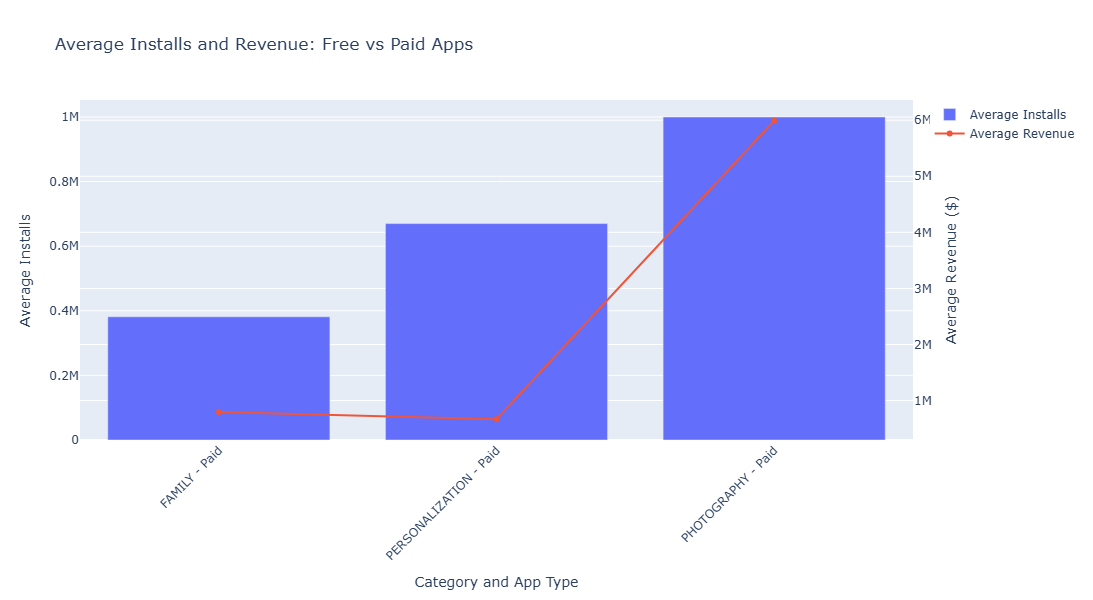

In [70]:
import plotly.graph_objects as go

fig = go.Figure()

# Average Installs
fig.add_trace(
    go.Bar(
        x=[
            f"{row['Category']} - {row['App_Type']}"
            for _, row in task3_summary.iterrows()
        ],
        y=task3_summary['Average_Installs'],
        name='Average Installs'
    )
)

# Average Revenue
fig.add_trace(
    go.Scatter(
        x=[
            f"{row['Category']} - {row['App_Type']}"
            for _, row in task3_summary.iterrows()
        ],
        y=task3_summary['Average_Revenue'],
        name='Average Revenue',
        yaxis='y2',
        mode='lines+markers'
    )
)

fig.update_layout(
    title='Average Installs and Revenue: Free vs Paid Apps',
    xaxis_title='Category and App Type',
    yaxis=dict(
        title='Average Installs'
    ),
    yaxis2=dict(
        title='Average Revenue ($)',
        overlaying='y',
        side='right'
    ),
    height=600,
    xaxis_tickangle=-45
)

fig.show()

In [71]:
task4_df = apps_df.copy()

task4_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up


In [72]:
print(task4_df.columns.tolist())

['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


In [73]:
task4_df['Reviews'] = pd.to_numeric(
    task4_df['Reviews'],
    errors='coerce'
)

task4_df[['App', 'Category', 'Reviews']].head()

,App,Category,Reviews
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,159.0
1,Coloring book moana,ART_AND_DESIGN,967.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,87510.0
3,Sketch - Draw & Paint,ART_AND_DESIGN,215644.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,967.0


In [74]:
task4_df = task4_df[
    task4_df['Category']
    .astype(str)
    .str.upper()
    .str.startswith(('E', 'C', 'B'))
].copy()

print("Categories remaining:")
print(task4_df['Category'].unique())

Categories remaining:
<ArrowStringArray>
[             'BEAUTY', 'BOOKS_AND_REFERENCE',            'BUSINESS',
              'COMICS',       'COMMUNICATION',           'EDUCATION',
       'ENTERTAINMENT',              'EVENTS']
Length: 8, dtype: str


In [75]:
task4_df = task4_df[
    (task4_df['Reviews'] > 500) &
    (~task4_df['App'].astype(str).str.upper().str.startswith(('X', 'Y', 'Z'))) &
    (~task4_df['App'].astype(str).str.upper().str.contains('S', na=False))
].copy()

print("Number of apps after filtering:", len(task4_df))
print("\nRemaining categories:")
print(task4_df['Category'].unique())

Number of apps after filtering: 245

Remaining categories:
<ArrowStringArray>
[             'BEAUTY', 'BOOKS_AND_REFERENCE',            'BUSINESS',
              'COMICS',       'COMMUNICATION',           'EDUCATION',
       'ENTERTAINMENT',              'EVENTS']
Length: 8, dtype: str


In [76]:
task4_df['Last Updated'] = pd.to_datetime(
    task4_df['Last Updated'],
    errors='coerce'
)

print(task4_df['Last Updated'].dtype)

datetime64[us]


In [77]:
# Create a Month column
task4_df['Month'] = task4_df['Last Updated'].dt.to_period('M').dt.to_timestamp()

# Make sure Installs is numeric
task4_df['Installs'] = (
    task4_df['Installs']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
)

task4_df['Installs'] = pd.to_numeric(
    task4_df['Installs'],
    errors='coerce'
)

# Monthly total installs by category
task4_summary = (
    task4_df
    .groupby(['Month', 'Category'], as_index=False)['Installs']
    .sum()
    .sort_values(['Category', 'Month'])
)

task4_summary.head(10)

,Month,Category,Installs
46,2018-03-01,BEAUTY,5000
58,2018-06-01,BEAUTY,1000000
64,2018-07-01,BEAUTY,1000000
72,2018-08-01,BEAUTY,100000
5,2014-10-01,BOOKS_AND_REFERENCE,500000
6,2014-11-01,BOOKS_AND_REFERENCE,5000000
10,2015-07-01,BOOKS_AND_REFERENCE,10000000
18,2016-06-01,BOOKS_AND_REFERENCE,60000
21,2016-08-01,BOOKS_AND_REFERENCE,100000
27,2017-02-01,BOOKS_AND_REFERENCE,100000


In [78]:
# Calculate month-over-month install growth for each category
task4_summary['MoM_Growth'] = (
    task4_summary
    .groupby('Category')['Installs']
    .pct_change() * 100
)

# Identify periods where installs increased by more than 20%
task4_summary['Significant_Growth'] = (
    task4_summary['MoM_Growth'] > 20
)

task4_summary.head(15)

,Month,Category,Installs,MoM_Growth,Significant_Growth
46,2018-03-01,BEAUTY,5000,NaN,False
58,2018-06-01,BEAUTY,1000000,19900.000000,True
64,2018-07-01,BEAUTY,1000000,0.000000,False
72,2018-08-01,BEAUTY,100000,-90.000000,False
5,2014-10-01,BOOKS_AND_REFERENCE,500000,NaN,False
6,2014-11-01,BOOKS_AND_REFERENCE,5000000,900.000000,True
10,2015-07-01,BOOKS_AND_REFERENCE,10000000,100.000000,True
18,2016-06-01,BOOKS_AND_REFERENCE,60000,-99.400000,False
21,2016-08-01,BOOKS_AND_REFERENCE,100000,66.666667,True
27,2017-02-01,BOOKS_AND_REFERENCE,100000,0.000000,False


In [79]:
# Translate required categories for the graph
category_translation = {
    'BEAUTY': 'सौंदर्य',
    'BUSINESS': 'வணிகம்',
    'DATING': 'Dating'
}

task4_summary['Graph_Category'] = (
    task4_summary['Category']
    .map(category_translation)
    .fillna(task4_summary['Category'])
)

print(task4_summary[['Category', 'Graph_Category']].drop_duplicates())

               Category       Graph_Category
46               BEAUTY              सौंदर्य
5   BOOKS_AND_REFERENCE  BOOKS_AND_REFERENCE
2              BUSINESS               வணிகம்
28               COMICS               COMICS
0         COMMUNICATION        COMMUNICATION
4             EDUCATION            EDUCATION
14        ENTERTAINMENT        ENTERTAINMENT
57               EVENTS               EVENTS


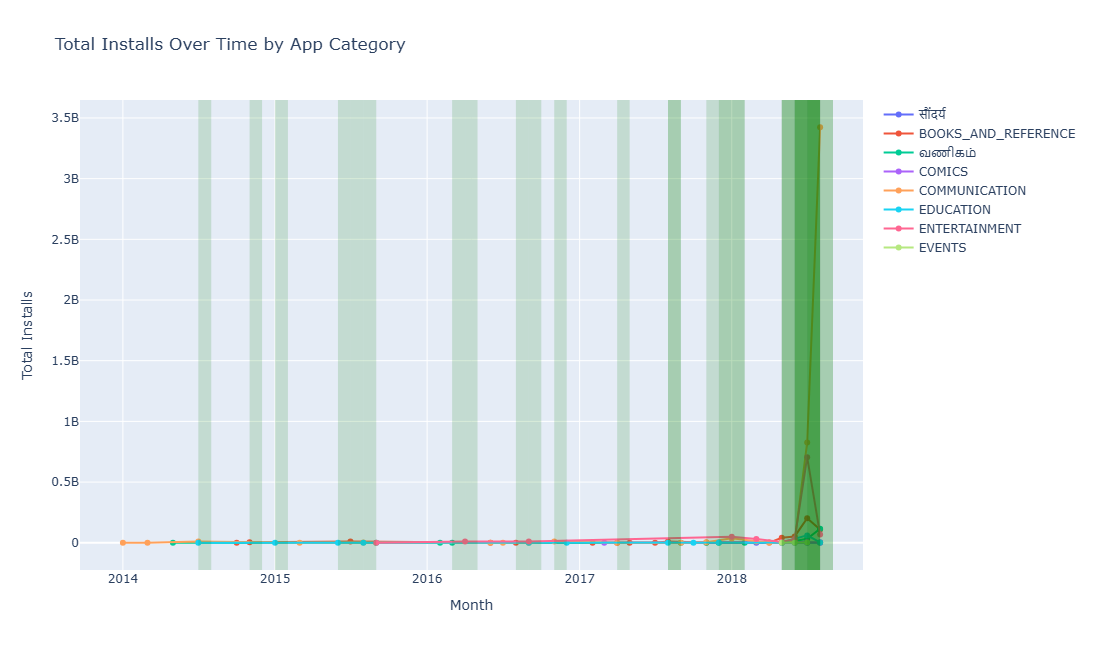

In [80]:
import plotly.graph_objects as go

fig = go.Figure()

# Add a line for each category
for category in task4_summary['Graph_Category'].unique():
    category_data = task4_summary[
        task4_summary['Graph_Category'] == category
    ].sort_values('Month')

    fig.add_trace(
        go.Scatter(
            x=category_data['Month'],
            y=category_data['Installs'],
            mode='lines+markers',
            name=category
        )
    )

# Highlight periods where MoM growth is greater than 20%
for _, row in task4_summary[
    task4_summary['Significant_Growth'] == True
].iterrows():

    fig.add_vrect(
        x0=row['Month'],
        x1=row['Month'] + pd.DateOffset(months=1),
        fillcolor='green',
        opacity=0.15,
        line_width=0
    )

fig.update_layout(
    title='Total Installs Over Time by App Category',
    xaxis_title='Month',
    yaxis_title='Total Installs',
    height=650,
    hovermode='x unified'
)

fig.show()

In [81]:
task5_df = apps_df.copy()

task5_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up


In [82]:
print(reviews_df.columns.tolist())

['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']


In [83]:
print(reviews_df[['App', 'Sentiment_Subjectivity']].head())

                     App  Sentiment_Subjectivity
0  10 Best Foods for You                0.533333
1  10 Best Foods for You                0.288462
2  10 Best Foods for You                     NaN
3  10 Best Foods for You                0.875000
4  10 Best Foods for You                0.300000


In [84]:
# Calculate average sentiment subjectivity for each app
task5_subjectivity = (
    reviews_df
    .groupby('App', as_index=False)['Sentiment_Subjectivity']
    .mean()
)

task5_subjectivity.head()

,App,Sentiment_Subjectivity
0,10 Best Foods for You,0.495455
1,104 找工作 - 找工作 找打工 找兼職 履歷健檢 履歷診療室,0.545516
2,11st,0.443957
3,1800 Contacts - Lens Store,0.591098
4,1LINE – One Line with One Touch,0.557315


In [85]:
# Add average sentiment subjectivity to Task 5 dataframe
task5_df = task5_df.merge(
    task5_subjectivity,
    on='App',
    how='left'
)

task5_df[['App', 'Rating', 'Reviews', 'Sentiment_Subjectivity']].head()

,App,Rating,Reviews,Sentiment_Subjectivity
0,Photo Editor & Candy Camera & Grid & ScrapBook,4.1,159,NaN
1,Coloring book moana,3.9,967,0.64154
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",4.7,87510,NaN
3,Sketch - Draw & Paint,4.5,215644,NaN
4,Pixel Draw - Number Art Coloring Book,4.3,967,NaN


In [86]:
# Clean numeric columns for Task 5

task5_df['Rating'] = pd.to_numeric(
    task5_df['Rating'],
    errors='coerce'
)

task5_df['Reviews'] = pd.to_numeric(
    task5_df['Reviews'],
    errors='coerce'
)

task5_df['Installs'] = (
    task5_df['Installs']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
)

task5_df['Installs'] = pd.to_numeric(
    task5_df['Installs'],
    errors='coerce'
)

task5_df['Size'] = (
    task5_df['Size']
    .astype(str)
    .str.replace('M', '', regex=False)
)

task5_df['Size'] = pd.to_numeric(
    task5_df['Size'],
    errors='coerce'
)

task5_df[['App', 'Rating', 'Reviews', 'Installs', 'Size']].head()

,App,Rating,Reviews,Installs,Size
0,Photo Editor & Candy Camera & Grid & ScrapBook,4.1,159.0,10000.0,19.0
1,Coloring book moana,3.9,967.0,500000.0,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",4.7,87510.0,5000000.0,8.7
3,Sketch - Draw & Paint,4.5,215644.0,50000000.0,25.0
4,Pixel Draw - Number Art Coloring Book,4.3,967.0,100000.0,2.8


In [87]:
# Task 5 - Apply all required filters

task5_categories = [
    'GAME',
    'BEAUTY',
    'BUSINESS',
    'COMICS',
    'COMMUNICATION',
    'DATING',
    'ENTERTAINMENT',
    'SOCIAL',
    'EVENTS'
]

task5_df = task5_df[
    (task5_df['Rating'] > 3.5) &
    (task5_df['Category'].isin(task5_categories)) &
    (task5_df['Reviews'] > 500) &
    (~task5_df['App'].astype(str).str.upper().str.contains('S', na=False)) &
    (task5_df['Sentiment_Subjectivity'] > 0.5) &
    (task5_df['Installs'] > 50000)
].copy()

print("Number of apps after filtering:", len(task5_df))
print("\nRemaining categories:")
print(task5_df['Category'].unique())

Number of apps after filtering: 50

Remaining categories:
<ArrowStringArray>
['BUSINESS', 'COMMUNICATION', 'DATING', 'ENTERTAINMENT', 'GAME', 'SOCIAL']
Length: 6, dtype: str


In [88]:
# Task 5 - Translate categories for the graph

category_translation_task5 = {
    'BEAUTY': 'सौंदर्य',
    'BUSINESS': 'வணிகம்',
    'DATING': 'Dating'
}

task5_df['Graph_Category'] = (
    task5_df['Category']
    .map(category_translation_task5)
    .fillna(task5_df['Category'])
)

print(
    task5_df[['Category', 'Graph_Category']]
    .drop_duplicates()
)

           Category Graph_Category
198        BUSINESS         வணிகம்
360   COMMUNICATION  COMMUNICATION
485          DATING         Dating
886   ENTERTAINMENT  ENTERTAINMENT
1664           GAME           GAME
2600         SOCIAL         SOCIAL


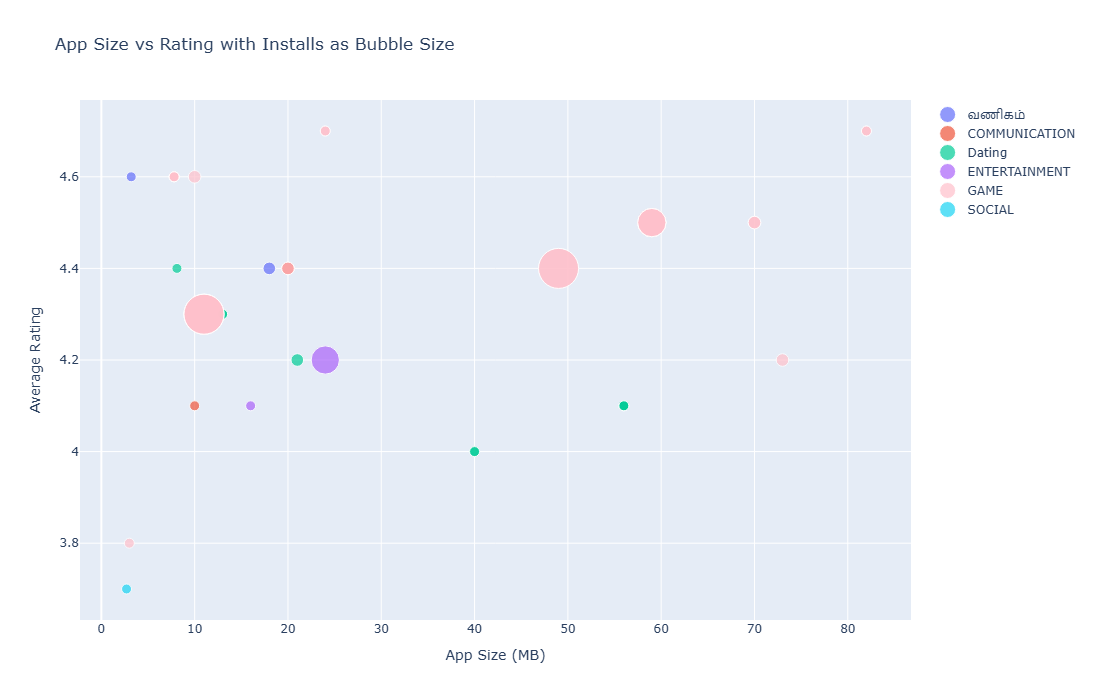

In [89]:
# Task 5 - Bubble Chart

import plotly.graph_objects as go

fig = go.Figure()

# Add each category as a separate trace
for category in task5_df['Graph_Category'].unique():

    category_data = task5_df[
        task5_df['Graph_Category'] == category
    ].copy()

    # Highlight Game category in pink
    if category == 'GAME':
        marker_color = 'pink'
    else:
        marker_color = None

    fig.add_trace(
        go.Scatter(
            x=category_data['Size'],
            y=category_data['Rating'],
            mode='markers',
            name=category,
            text=category_data['App'],
            marker=dict(
                size=category_data['Installs'],
                sizemode='area',
                sizeref=2.0 * max(task5_df['Installs']) / (40 ** 2),
                sizemin=5,
                color=marker_color,
                opacity=0.7
            ),
            customdata=category_data[
                ['Installs', 'Reviews', 'Sentiment_Subjectivity']
            ],
            hovertemplate=
                '<b>%{text}</b><br>' +
                'Category: ' + category + '<br>' +
                'Size: %{x:.2f} MB<br>' +
                'Rating: %{y:.2f}<br>' +
                'Installs: %{customdata[0]:,}<br>' +
                'Reviews: %{customdata[1]:,}<br>' +
                'Subjectivity: %{customdata[2]:.2f}' +
                '<extra></extra>'
        )
    )

fig.update_layout(
    title='App Size vs Rating with Installs as Bubble Size',
    xaxis_title='App Size (MB)',
    yaxis_title='Average Rating',
    height=700,
    hovermode='closest'
)

fig.show()

In [90]:
task6_df = apps_df.copy()

task6_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up


In [91]:
# Task 6 - Clean required numeric columns

task6_df['Rating'] = pd.to_numeric(
    task6_df['Rating'],
    errors='coerce'
)

task6_df['Reviews'] = pd.to_numeric(
    task6_df['Reviews'],
    errors='coerce'
)

task6_df['Installs'] = (
    task6_df['Installs']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
)

task6_df['Installs'] = pd.to_numeric(
    task6_df['Installs'],
    errors='coerce'
)

task6_df['Size'] = (
    task6_df['Size']
    .astype(str)
    .str.replace('M', '', regex=False)
)

task6_df['Size'] = pd.to_numeric(
    task6_df['Size'],
    errors='coerce'
)

task6_df[['App', 'Category', 'Rating', 'Reviews', 'Installs', 'Size']].head()

,App,Category,Rating,Reviews,Installs,Size
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,10000.0,19.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,500000.0,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,5000000.0,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,50000000.0,25.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,100000.0,2.8


In [92]:
# Task 6 - Apply all required filters

task6_df = task6_df[
    (task6_df['Rating'] >= 4.2) &
    (~task6_df['App'].astype(str).str.contains(r'\d', na=False)) &
    (task6_df['Category'].astype(str).str.upper().str.startswith(('T', 'P'))) &
    (task6_df['Reviews'] > 1000) &
    (task6_df['Size'] >= 20) &
    (task6_df['Size'] <= 80)
].copy()

print("Number of apps after filtering:", len(task6_df))
print("\nCategories included:")
print(task6_df['Category'].unique())

Number of apps after filtering: 139

Categories included:
<ArrowStringArray>
[     'PHOTOGRAPHY', 'TRAVEL_AND_LOCAL',            'TOOLS',
  'PERSONALIZATION',     'PRODUCTIVITY',        'PARENTING']
Length: 6, dtype: str


In [93]:
# Task 6 - Create monthly install summary

task6_df['Last Updated'] = pd.to_datetime(
    task6_df['Last Updated'],
    errors='coerce'
)

task6_df['Month'] = (
    task6_df['Last Updated']
    .dt.to_period('M')
    .dt.to_timestamp()
)

task6_summary = (
    task6_df
    .groupby(['Month', 'Category'], as_index=False)['Installs']
    .sum()
    .sort_values(['Category', 'Month'])
)

print(task6_summary.head(10))

        Month         Category    Installs
16 2018-03-01        PARENTING    100000.0
19 2018-05-01        PARENTING  10000000.0
26 2018-07-01        PARENTING    600000.0
2  2016-12-01  PERSONALIZATION   2000000.0
7  2017-09-01  PERSONALIZATION   1000000.0
11 2018-01-01  PERSONALIZATION  10000000.0
14 2018-02-01  PERSONALIZATION  10000000.0
22 2018-06-01  PERSONALIZATION  10000000.0
27 2018-07-01  PERSONALIZATION  11500000.0
32 2018-08-01  PERSONALIZATION  20000000.0


In [94]:
# Task 6 - Calculate month-over-month growth

task6_summary['MoM_Growth'] = (
    task6_summary
    .groupby('Category')['Installs']
    .pct_change() * 100
)

task6_summary['Significant_Growth'] = (
    task6_summary['MoM_Growth'] > 25
)

print(
    task6_summary[
        ['Month', 'Category', 'Installs', 'MoM_Growth', 'Significant_Growth']
    ].head(15)
)

        Month         Category    Installs   MoM_Growth  Significant_Growth
16 2018-03-01        PARENTING    100000.0          NaN               False
19 2018-05-01        PARENTING  10000000.0  9900.000000                True
26 2018-07-01        PARENTING    600000.0   -94.000000               False
2  2016-12-01  PERSONALIZATION   2000000.0          NaN               False
7  2017-09-01  PERSONALIZATION   1000000.0   -50.000000               False
11 2018-01-01  PERSONALIZATION  10000000.0   900.000000                True
14 2018-02-01  PERSONALIZATION  10000000.0     0.000000               False
22 2018-06-01  PERSONALIZATION  10000000.0     0.000000               False
27 2018-07-01  PERSONALIZATION  11500000.0    15.000000               False
32 2018-08-01  PERSONALIZATION  20000000.0    73.913043                True
0  2014-11-01      PHOTOGRAPHY   1000000.0          NaN               False
3  2017-03-01      PHOTOGRAPHY  50000000.0  4900.000000                True
4  2017-06-0

In [95]:
# Task 6 - Translate category names for the graph legend

category_translation_task6 = {
    'TRAVEL_AND_LOCAL': 'Voyage et local',   # French
    'PRODUCTIVITY': 'Productividad',         # Spanish
    'PHOTOGRAPHY': '写真'                     # Japanese
}

task6_summary['Graph_Category'] = (
    task6_summary['Category']
    .map(category_translation_task6)
    .fillna(task6_summary['Category'])
)

print(
    task6_summary[
        ['Category', 'Graph_Category']
    ].drop_duplicates()
)

            Category   Graph_Category
16         PARENTING        PARENTING
2    PERSONALIZATION  PERSONALIZATION
0        PHOTOGRAPHY               写真
1       PRODUCTIVITY    Productividad
6              TOOLS            TOOLS
9   TRAVEL_AND_LOCAL  Voyage et local


In [96]:
# Task 6 - Calculate cumulative installs

task6_summary = task6_summary.sort_values(
    ['Category', 'Month']
).copy()

task6_summary['Cumulative_Installs'] = (
    task6_summary
    .groupby('Category')['Installs']
    .cumsum()
)

print(
    task6_summary[
        ['Month', 'Category', 'Installs', 'Cumulative_Installs']
    ].head(15)
)

        Month         Category    Installs  Cumulative_Installs
16 2018-03-01        PARENTING    100000.0             100000.0
19 2018-05-01        PARENTING  10000000.0           10100000.0
26 2018-07-01        PARENTING    600000.0           10700000.0
2  2016-12-01  PERSONALIZATION   2000000.0            2000000.0
7  2017-09-01  PERSONALIZATION   1000000.0            3000000.0
11 2018-01-01  PERSONALIZATION  10000000.0           13000000.0
14 2018-02-01  PERSONALIZATION  10000000.0           23000000.0
22 2018-06-01  PERSONALIZATION  10000000.0           33000000.0
27 2018-07-01  PERSONALIZATION  11500000.0           44500000.0
32 2018-08-01  PERSONALIZATION  20000000.0           64500000.0
0  2014-11-01      PHOTOGRAPHY   1000000.0            1000000.0
3  2017-03-01      PHOTOGRAPHY  50000000.0           51000000.0
4  2017-06-01      PHOTOGRAPHY  10000000.0           61000000.0
5  2017-07-01      PHOTOGRAPHY  15000000.0           76000000.0
8  2017-10-01      PHOTOGRAPHY   5000000

In [97]:
# Task 6 - Identify months with significant growth

highlight_months_task6 = (
    task6_summary
    .groupby('Month')['Significant_Growth']
    .any()
)

task6_summary['Highlight_Month'] = (
    task6_summary['Month'].map(highlight_months_task6)
)

print(
    task6_summary[
        ['Month', 'Category', 'MoM_Growth',
         'Significant_Growth', 'Highlight_Month']
    ]
)

        Month          Category    MoM_Growth  Significant_Growth  \
16 2018-03-01         PARENTING           NaN               False   
19 2018-05-01         PARENTING   9900.000000                True   
26 2018-07-01         PARENTING    -94.000000               False   
2  2016-12-01   PERSONALIZATION           NaN               False   
7  2017-09-01   PERSONALIZATION    -50.000000               False   
11 2018-01-01   PERSONALIZATION    900.000000                True   
14 2018-02-01   PERSONALIZATION      0.000000               False   
22 2018-06-01   PERSONALIZATION      0.000000               False   
27 2018-07-01   PERSONALIZATION     15.000000               False   
32 2018-08-01   PERSONALIZATION     73.913043                True   
0  2014-11-01       PHOTOGRAPHY           NaN               False   
3  2017-03-01       PHOTOGRAPHY   4900.000000                True   
4  2017-06-01       PHOTOGRAPHY    -80.000000               False   
5  2017-07-01       PHOTOGRAPHY   

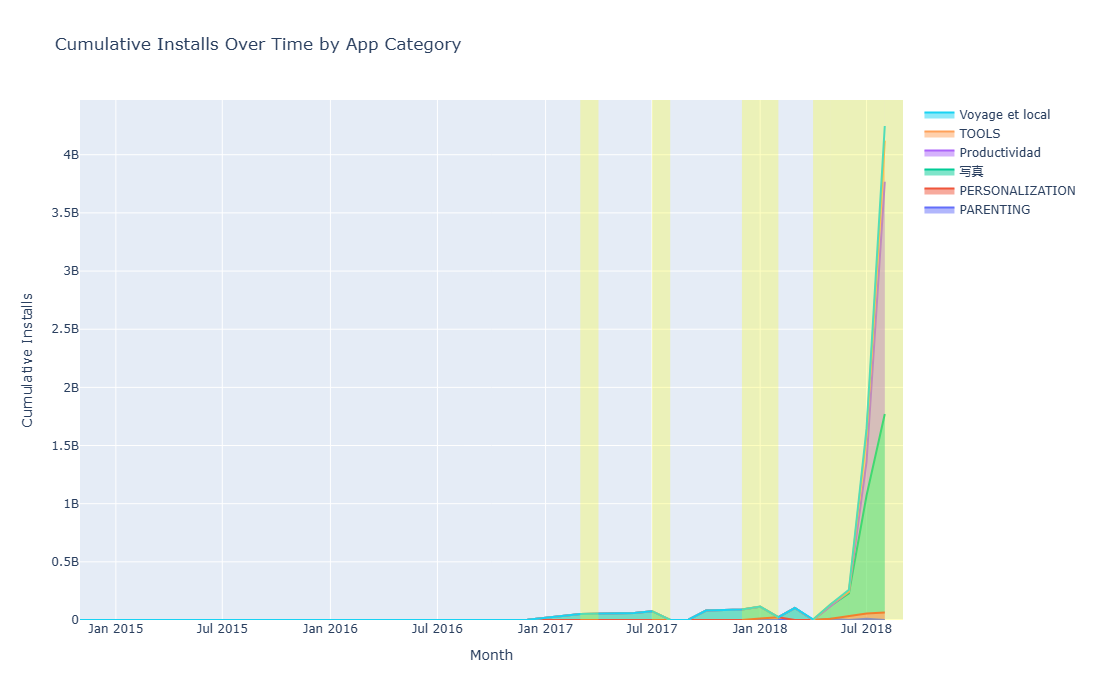

In [98]:
# Task 6 - Create stacked area chart

import plotly.graph_objects as go

fig = go.Figure()

for category in task6_summary['Graph_Category'].unique():

    category_data = task6_summary[
        task6_summary['Graph_Category'] == category
    ].sort_values('Month')

    fig.add_trace(
        go.Scatter(
            x=category_data['Month'],
            y=category_data['Cumulative_Installs'],
            mode='lines',
            name=category,
            stackgroup='one',
            groupnorm=None
        )
    )

# Highlight months where any category had >25% MoM growth
highlighted_months = (
    task6_summary[
        task6_summary['Highlight_Month'] == True
    ]['Month']
    .drop_duplicates()
)

for month in highlighted_months:
    fig.add_vrect(
        x0=month,
        x1=month + pd.DateOffset(months=1),
        fillcolor='yellow',
        opacity=0.25,
        line_width=0
    )

fig.update_layout(
    title='Cumulative Installs Over Time by App Category',
    xaxis_title='Month',
    yaxis_title='Cumulative Installs',
    height=700,
    hovermode='x unified'
)

fig.show()

In [99]:
# ============================================================
# GOOGLE PLAY STORE ANALYTICS - COMPLETE HTML DASHBOARD
# ============================================================

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import pandas as pd
from datetime import datetime
from zoneinfo import ZoneInfo
import plotly.io as pio


# ------------------------------------------------------------
# 1. CREATE ALL FIGURES
# ------------------------------------------------------------

# =========================
# TASK 1 - GROUPED BAR
# =========================

fig1 = px.bar(
    top10_task1,
    x='Category',
    y=['Average_Rating', 'Total_Reviews'],
    barmode='group',
    title='Task 1: Top 10 Categories - Rating vs Reviews',
    labels={
        'Category': 'App Category',
        'value': 'Value',
        'variable': 'Metric'
    },
    text_auto='.2s'
)

fig1.update_layout(
    xaxis_tickangle=-45,
    height=600
)


# =========================
# TASK 2 - CHOROPLETH
# =========================

fig2 = px.choropleth(
    task2_map_data,
    locations='Country',
    color='Installs',
    animation_frame='Category',
    hover_name='Country_Name',
    hover_data={
        'Category': True,
        'Installs': ':,',
        'Highlight': True
    },
    locationmode='ISO-3',
    title='Task 2: Top 5 App Categories - Global Installs',
    color_continuous_scale='Viridis'
)

fig2.update_layout(
    height=650,
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth'
    )
)


# =========================
# TASK 3 - DUAL AXIS
# =========================

fig3 = go.Figure()

fig3.add_trace(
    go.Bar(
        x=[
            f"{row['Category']} - {row['App_Type']}"
            for _, row in task3_summary.iterrows()
        ],
        y=task3_summary['Average_Installs'],
        name='Average Installs'
    )
)

fig3.add_trace(
    go.Scatter(
        x=[
            f"{row['Category']} - {row['App_Type']}"
            for _, row in task3_summary.iterrows()
        ],
        y=task3_summary['Average_Revenue'],
        name='Average Revenue',
        yaxis='y2',
        mode='lines+markers'
    )
)

fig3.update_layout(
    title='Task 3: Average Installs vs Revenue',
    xaxis_title='Category and App Type',
    yaxis=dict(title='Average Installs'),
    yaxis2=dict(
        title='Average Revenue ($)',
        overlaying='y',
        side='right'
    ),
    height=600,
    xaxis_tickangle=-45
)


# =========================
# TASK 4 - TIME SERIES
# =========================

fig4 = go.Figure()

for category in task4_summary['Graph_Category'].unique():

    category_data = task4_summary[
        task4_summary['Graph_Category'] == category
    ].sort_values('Month')

    fig4.add_trace(
        go.Scatter(
            x=category_data['Month'],
            y=category_data['Installs'],
            mode='lines+markers',
            name=category
        )
    )

for _, row in task4_summary[
    task4_summary['Significant_Growth'] == True
].iterrows():

    fig4.add_vrect(
        x0=row['Month'],
        x1=row['Month'] + pd.DateOffset(months=1),
        fillcolor='green',
        opacity=0.15,
        line_width=0
    )

fig4.update_layout(
    title='Task 4: Total Installs Over Time',
    xaxis_title='Month',
    yaxis_title='Total Installs',
    height=650,
    hovermode='x unified'
)


# =========================
# TASK 5 - BUBBLE CHART
# =========================

fig5 = go.Figure()

for category in task5_df['Graph_Category'].unique():

    category_data = task5_df[
        task5_df['Graph_Category'] == category
    ].copy()

    if category == 'GAME':
        marker_color = 'pink'
    else:
        marker_color = None

    fig5.add_trace(
        go.Scatter(
            x=category_data['Size'],
            y=category_data['Rating'],
            mode='markers',
            name=category,
            text=category_data['App'],
            marker=dict(
                size=category_data['Installs'],
                sizemode='area',
                sizeref=(
                    2.0 * max(task5_df['Installs']) / (40 ** 2)
                ),
                sizemin=5,
                color=marker_color,
                opacity=0.7
            ),
            customdata=category_data[
                ['Installs', 'Reviews', 'Sentiment_Subjectivity']
            ],
            hovertemplate=
                '<b>%{text}</b><br>' +
                'Category: ' + category + '<br>' +
                'Size: %{x:.2f} MB<br>' +
                'Rating: %{y:.2f}<br>' +
                'Installs: %{customdata[0]:,}<br>' +
                'Reviews: %{customdata[1]:,}<br>' +
                'Subjectivity: %{customdata[2]:.2f}' +
                '<extra></extra>'
        )
    )

fig5.update_layout(
    title='Task 5: App Size vs Rating',
    xaxis_title='App Size (MB)',
    yaxis_title='Average Rating',
    height=700,
    hovermode='closest'
)


# =========================
# TASK 6 - STACKED AREA
# =========================

fig6 = go.Figure()

for category in task6_summary['Graph_Category'].unique():

    category_data = task6_summary[
        task6_summary['Graph_Category'] == category
    ].sort_values('Month')

    fig6.add_trace(
        go.Scatter(
            x=category_data['Month'],
            y=category_data['Cumulative_Installs'],
            mode='lines',
            name=category,
            stackgroup='one'
        )
    )

highlighted_months = (
    task6_summary[
        task6_summary['Highlight_Month'] == True
    ]['Month']
    .drop_duplicates()
)

for month in highlighted_months:

    fig6.add_vrect(
        x0=month,
        x1=month + pd.DateOffset(months=1),
        fillcolor='yellow',
        opacity=0.25,
        line_width=0
    )

fig6.update_layout(
    title='Task 6: Cumulative Installs Over Time',
    xaxis_title='Month',
    yaxis_title='Cumulative Installs',
    height=700,
    hovermode='x unified'
)


# ------------------------------------------------------------
# 2. CONVERT FIGURES TO HTML
# ------------------------------------------------------------

html1 = pio.to_html(
    fig1,
    full_html=False,
    include_plotlyjs=False
)

html2 = pio.to_html(
    fig2,
    full_html=False,
    include_plotlyjs=False
)

html3 = pio.to_html(
    fig3,
    full_html=False,
    include_plotlyjs=False
)

html4 = pio.to_html(
    fig4,
    full_html=False,
    include_plotlyjs=False
)

html5 = pio.to_html(
    fig5,
    full_html=False,
    include_plotlyjs=False
)

html6 = pio.to_html(
    fig6,
    full_html=False,
    include_plotlyjs=False
)


# ------------------------------------------------------------
# 3. CREATE DASHBOARD HTML
# ------------------------------------------------------------

dashboard_html = f"""
<!DOCTYPE html>

<html>

<head>

<meta charset="UTF-8">

<title>Google Play Store Analytics Dashboard</title>

<script src="https://cdn.plot.ly/plotly-2.35.2.min.js"></script>

<style>

body {{
    margin: 0;
    font-family: Arial, sans-serif;
    background: #f4f6f8;
}}

.header {{
    background: #202124;
    color: white;
    padding: 25px;
    text-align: center;
}}

.header h1 {{
    margin: 0;
    font-size: 30px;
}}

.header p {{
    margin-top: 8px;
    color: #d0d0d0;
}}

.time-box {{
    text-align: center;
    background: white;
    padding: 15px;
    margin: 15px;
    border-radius: 10px;
    font-size: 18px;
}}

.dashboard {{
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 20px;
    padding: 20px;
}}

.card {{
    background: white;
    border-radius: 12px;
    padding: 15px;
    box-shadow: 0 3px 10px rgba(0,0,0,0.08);
}}

.full {{
    grid-column: 1 / -1;
}}

.locked {{
    text-align: center;
    padding: 100px 20px;
    font-size: 22px;
    color: #666;
}}

@media (max-width: 900px) {{
    .dashboard {{
        grid-template-columns: 1fr;
    }}
}}

</style>

</head>


<body>


<div class="header">

<h1>Google Play Store Analytics Dashboard</h1>

<p>Interactive Analysis of Google Play Store Applications</p>

</div>


<div class="time-box">

Current India Time:
<span id="currentTime">Loading...</span>

<br>

<span id="activeTasks"></span>

</div>


<div class="dashboard">


<div class="card" id="task1">
{html1}
</div>


<div class="card" id="task2">
{html2}
</div>


<div class="card" id="task3">
{html3}
</div>


<div class="card" id="task4">
{html4}
</div>


<div class="card" id="task5">
{html5}
</div>


<div class="card" id="task6">
{html6}
</div>


</div>


<script>


// ----------------------------------------------------
// INDIA TIME
// ----------------------------------------------------

function getIndiaTime() {{

    const now = new Date();

    const indiaTime = new Date(
        now.toLocaleString(
            "en-US",
            {{timeZone: "Asia/Kolkata"}}
        )
    );

    return indiaTime;

}}


// ----------------------------------------------------
// TIME WINDOW CHECK
// ----------------------------------------------------

function isBetween(hour, start, end) {{

    return hour >= start && hour < end;

}}


// ----------------------------------------------------
// CONTROL TASK VISIBILITY
// ----------------------------------------------------

function updateDashboard() {{

    const indiaTime = getIndiaTime();

    const hours = indiaTime.getHours();

    const minutes = indiaTime.getMinutes();

    const timeString =
        String(hours).padStart(2, '0')
        + ":"
        + String(minutes).padStart(2, '0');

    document.getElementById(
        "currentTime"
    ).innerText = timeString + " IST";


    const tasks = {{

        task1: isBetween(hours, 15, 17),

        task2: isBetween(hours, 18, 20),

        task3: isBetween(hours, 13, 14),

        task4: isBetween(hours, 18, 21),

        task5: isBetween(hours, 17, 19),

        task6: isBetween(hours, 16, 18)

    }};


    let active = [];


    for (const task in tasks) {{

        const element =
            document.getElementById(task);

        if (tasks[task]) {{

            element.style.display = "block";

            active.push(
                task.replace("task", "Task ")
            );

        }} else {{

            element.style.display = "none";

        }}

    }}


    if (active.length > 0) {{

        document.getElementById(
            "activeTasks"
        ).innerHTML =
            "Currently active: <b>"
            + active.join(", ")
            + "</b>";

    }} else {{

        document.getElementById(
            "activeTasks"
        ).innerHTML =
            "No task visualization is active at this time.";

    }}

}}


// Update immediately
updateDashboard();


// Update every minute
setInterval(
    updateDashboard,
    60000
);

</script>


</body>

</html>
"""


# ------------------------------------------------------------
# 4. SAVE DASHBOARD
# ------------------------------------------------------------

dashboard_file = "Google_Play_Store_Analytics_Dashboard.html"

with open(
    dashboard_file,
    "w",
    encoding="utf-8"
) as file:

    file.write(dashboard_html)


print("Dashboard created successfully!")
print("File:", dashboard_file)

Dashboard created successfully!
File: Google_Play_Store_Analytics_Dashboard.html
